In [1]:
import torch
import pandas as pd
from matplotlib import pyplot as plt
import joblib
import numpy as np
from environments.GH_env import*

322.8714145722115


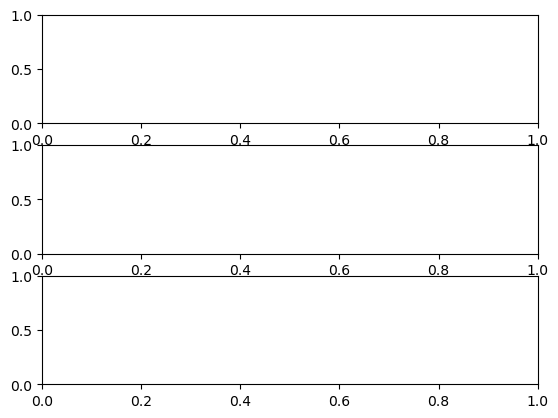

In [2]:
gh_env = GH_env()
T_ext = 300
R_n(300, 20, 25, 80)
T_atm = f_n*T_ext + 0.0552*(1-f_n)*(T_ext + 273.15)**1.5 
print(T_atm)


In [3]:
N = 144
x_s = np.zeros((N+1, 3))
x_s[0] = gh_env.reset()
for i in range(N):
    x_s[i+1] = gh_env.step(np.array([0]))

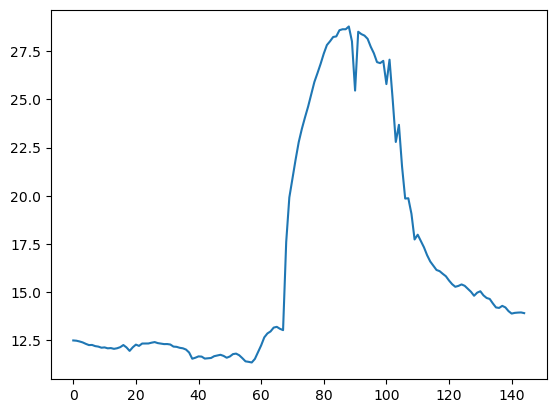

In [9]:
plt.plot(x_s[:,0])

In [5]:
def R_n(I, T_inv, T_ext, RH_ext):
    """Calculates the radiation heat transfer [W] """

    T_atm = f_n*(T_ext + 273.15) + 0.0552*(1-f_n)*(T_ext + 273.15)**1.5 
    eo_ext = 6.1078*np.exp(17.269*T_ext/(T_ext+237.3)) # presión parcial vapor [hPa]
    ea_ext = eo_ext*RH_ext/100  
    epsilon_atm = 1-np.exp(-10*ea_ext/T_ext)

    R_sol = A_g*I*(alpha_inv + tau_inv*(alpha_c*f_c+alpha_g*(1-f_c))) # [W]
    print(R_sol)
    R_ter = A_cu*sigma*tau_inv*(epsilon_atm*T_atm**4 - epsilon_inv*((T_inv + T_ext)*.5+273.15)**4) # [W]
    print(R_ter)
    return R_sol + R_ter

R_n(300, 20, 25, 80), Rn(300)

13205.52
2507.1069781853535


(15712.626978185353, 117.79903891281016)

In [6]:
R_n(300, 20, 25, 80)/((rho_air*c_pa + 100*c_pv/1000)*V_inv) # variacion de temepratura por radiación


13205.52
2507.1069781853535


0.07255273444605315

In [7]:
Q_g(20, 18)

1840.0

In [8]:
ts = 60  # [s] aparentemente a 60 [s] salva
T = 600  # [h]
N = T//ts # 1 hour
x_0 = 15.0
x = x_0
x_s = np.zeros(N)
for i in range(N):
    x = x + ts*x_ode(x)
    x_s[i] = x

t = np.linspace(ts, T, N)

In [9]:
ts = 10  # [s] aparentemente a 60 [s] salva
T = 600  # [h]
N = int(T//ts) # 1 hour
x_0 = np.array([20, 25, 15.0])
x = x_0
x_s = np.zeros((N+1, 3))
x_s[0] = x
d = np.array([300, 20, 45, .8])
for i in range(N):
    dx = GH_climate_ode(x, d, np.array([1.0]))
    x_s[i+1] = x_s[i] + ts*dx
    #print(dx)

t = np.linspace(ts, T, N)

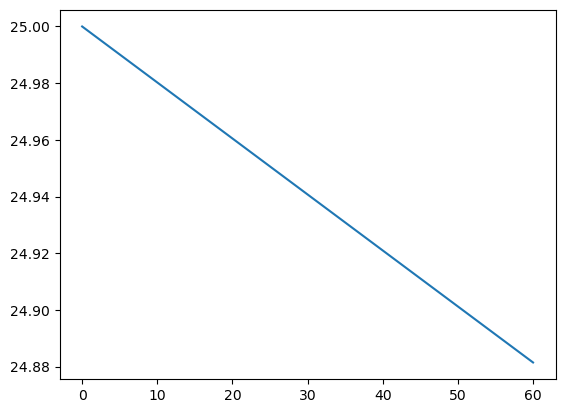

In [10]:
plt.plot(x_s[:,1])

ValueError: x and y must have same first dimension, but have shapes (60,) and (61, 3)

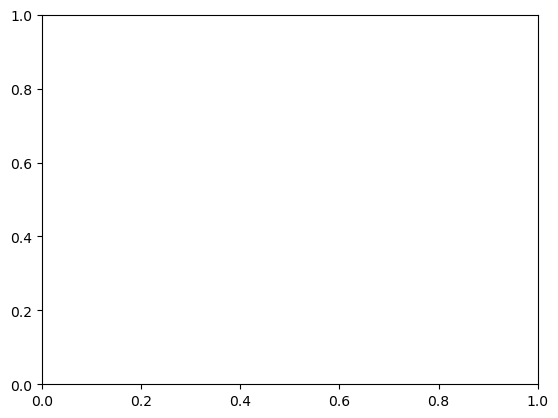

In [11]:
plt.plot(t, x_s)

Text(0.5, 1.0, 'RH_ext')

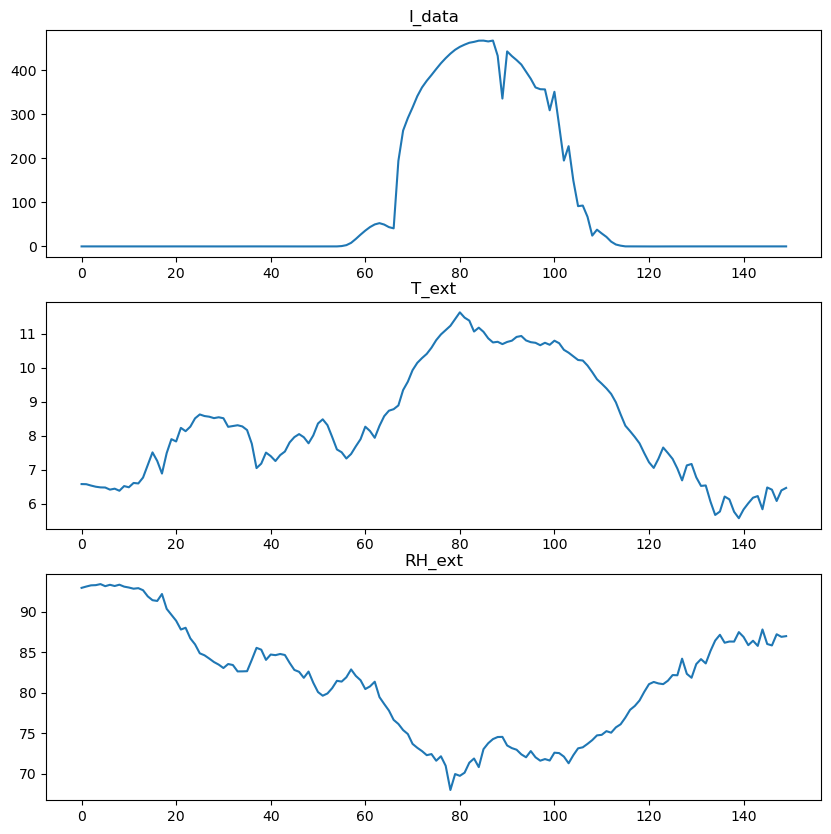

In [ ]:
fig, axs = plt.subplots(3,1, figsize=(10,10))
axs[0].plot(gh_env.I_data)
axs[0].set_title('I_data')

axs[1].plot(gh_env.T_ext_data)
axs[1].set_title('T_ext')

axs[2].plot(gh_env.RH_ext_data)
axs[2].set_title('RH_ext')


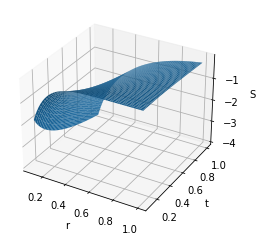

In [ ]:
list_of_paths = ["training_results\ems\DQN_20240506_051439",
                 "training_results\ems\DQN_20240506_050557",
                 "training_results\ems\DQN_20240506_045750",
                 "training_results\ems\DQN_20240506_044943",
                 ]

In [ ]:
import os

folder_path = ".\\training_results\\ems"
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]

models = []
scalers = []

for path in subfolders:
    models.append(torch.load(path + "\\policy.pt"))

    scalers.append(joblib.load(path + "\\scaler.pkl"))



In [ ]:
from environments.EMS_env import EMS_env

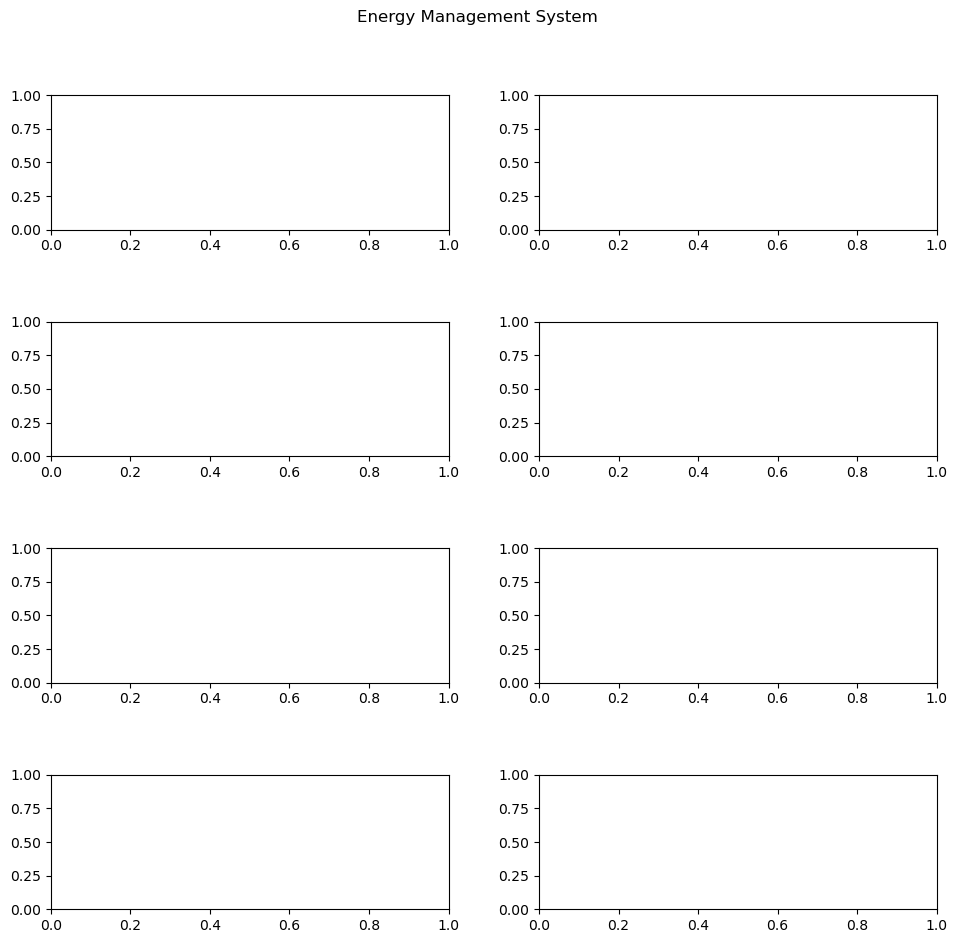

In [ ]:
env = EMS_env()

In [ ]:
stat_def = []
stat_pen = []
for i in range(len(models)):
    total_steps = 0
    num_deficit = 0
    num_pen = 0
    for i in range(20):
        total_steps += 288
        states, actions, rews = env.sample_trajectory(models[0], scalers[0], max_steps=288)
        num_deficit += np.sum(states[1:,-1]<0)
        num_pen += np.sum(np.logical_and(actions[:,0]>0, states[:-1,4]>=5))
   
    print(num_deficit/total_steps)
    print(num_pen/total_steps)
    stat_def.append(num_deficit/total_steps)
    stat_pen.append(num_pen/total_steps)
    




Accumulated power consumed: 0.32028837778299196
Accumulated power consumed: 0.21241438436889726
Accumulated power consumed: 0.3496483655723771
Accumulated power consumed: 0.24158735150094907
Accumulated power consumed: 0.2372404346601595
Accumulated power consumed: 0.33952337022080015
Accumulated power consumed: 0.42930003791071153
Accumulated power consumed: 0.18937745120650593
Accumulated power consumed: 0.3515701815879759
Accumulated power consumed: 0.359272569429768
Accumulated power consumed: 0.18940747636544436
Accumulated power consumed: 0.32030306656315405
Accumulated power consumed: 0.42861285345833094
Accumulated power consumed: 0.33608003379372553
Accumulated power consumed: 0.33279037584025456
Accumulated power consumed: 0.313106280032077
Accumulated power consumed: 0.2197754023400774
Accumulated power consumed: 0.45499142510623675
Accumulated power consumed: 0.31846066749368906
Accumulated power consumed: 0.23709439537786625
0.11631944444444445
0.0
Accumulated power consum

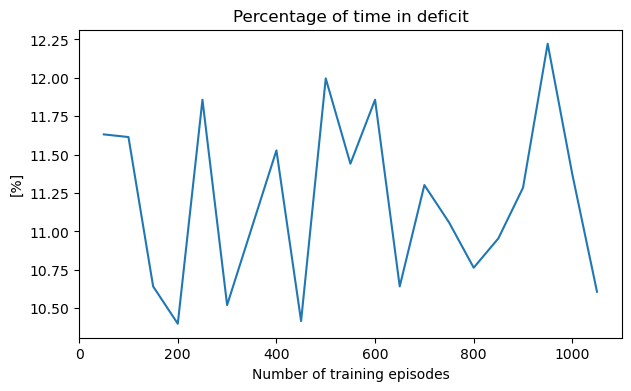

In [ ]:
a = np.linspace(50, 50*21 , len(stat_def))
plt.plot(a, np.array(stat_def)*100)
plt.title("Percentage of time in deficit")
plt.ylabel("[%]")
plt.xlabel("Number of training episodes")

fig = plt.gcf()
fig.set_size_inches(7, 4)
fig.savefig("deficit.png", dpi=300) 


In [ ]:
import numpy as np

a = np.array([True, False, True, False])
b = np.array([True, True, False, False])

result = np.logical_and(a, b)
print(result)


[ True False False False]


In [ ]:
env.show_sample(models[-1], scalers[-1])

Accumulated power consumed: 0.5180918000313575


In [ ]:
env.fig.savefig("sample.png", dpi=300)

: 